In [81]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings 
warnings.filterwarnings('ignore')


In [82]:
df=pd.read_csv("train.csv")
df.head()

,id,Sex,Age,Height,Weight,Duration,Heart_Rate,Body_Temp,Calories
0,0,male,36,189.0,82.0,26.0,101.0,41.0,150.0
1,1,female,64,163.0,60.0,8.0,85.0,39.7,34.0
2,2,female,51,161.0,64.0,7.0,84.0,39.8,29.0
3,3,male,20,192.0,90.0,25.0,105.0,40.7,140.0
4,4,female,38,166.0,61.0,25.0,102.0,40.6,146.0


In [83]:
df.shape

(750000, 9)

In [84]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 750000 entries, 0 to 749999
Data columns (total 9 columns):
 #   Column      Non-Null Count   Dtype  
---  ------      --------------   -----  
 0   id          750000 non-null  int64  
 1   Sex         750000 non-null  object 
 2   Age         750000 non-null  int64  
 3   Height      750000 non-null  float64
 4   Weight      750000 non-null  float64
 5   Duration    750000 non-null  float64
 6   Heart_Rate  750000 non-null  float64
 7   Body_Temp   750000 non-null  float64
 8   Calories    750000 non-null  float64
dtypes: float64(6), int64(2), object(1)
memory usage: 51.5+ MB


In [85]:
df.duplicated().sum()

np.int64(0)

In [86]:
df.columns

Index(['id', 'Sex', 'Age', 'Height', 'Weight', 'Duration', 'Heart_Rate',
       'Body_Temp', 'Calories'],
      dtype='object')

In [87]:
df.drop(columns='id',inplace=True)

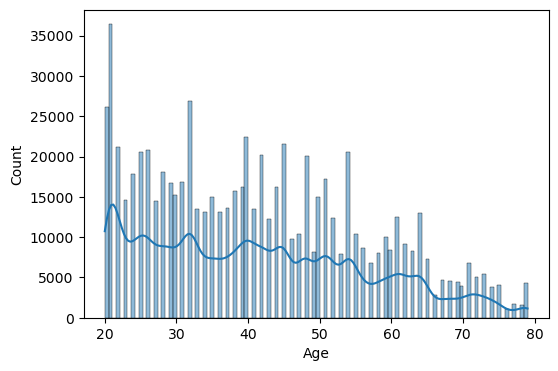

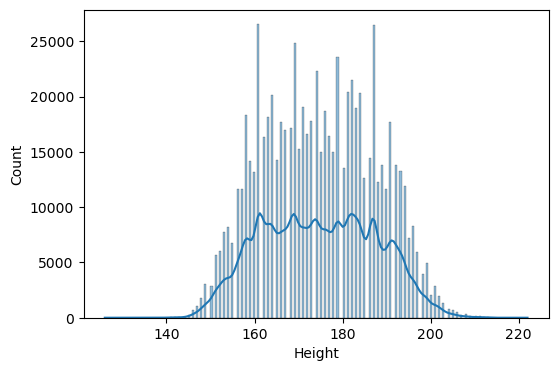

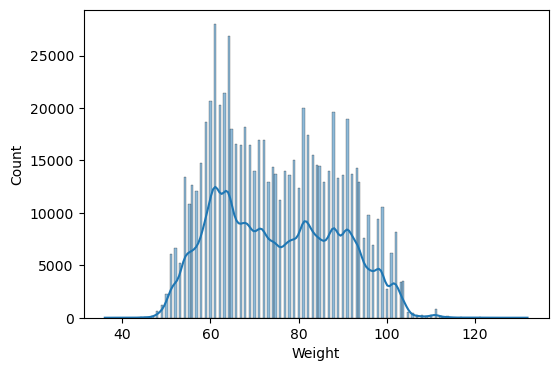

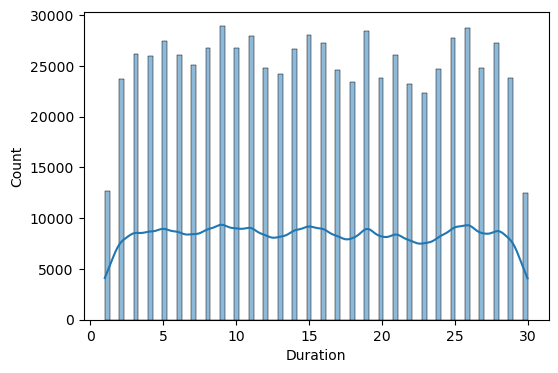

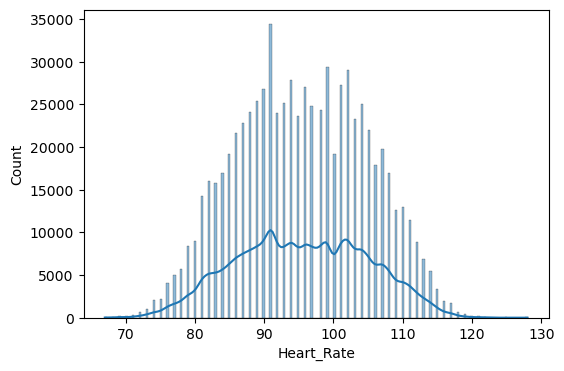

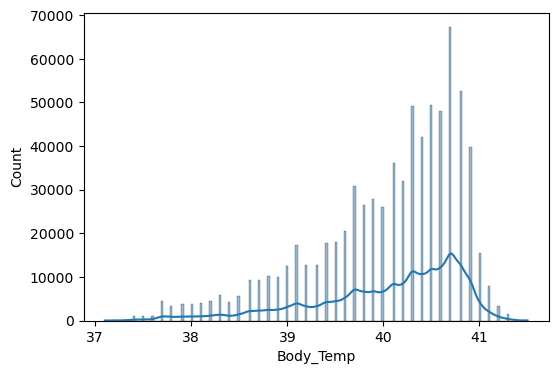

In [88]:
num_col=['Age', 'Height', 'Weight', 'Duration', 'Heart_Rate',
       'Body_Temp']
for i in num_col:
    plt.figure(figsize=(6,4))
    sns.histplot(df[i],kde=True)

<Axes: >

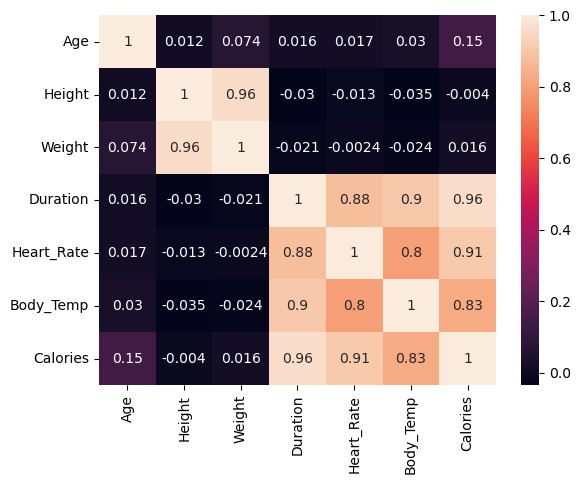

In [89]:
sns.heatmap(df.corr(numeric_only=True),annot=True)

In [ ]:
#SINCE HEIGHT AND WEIGHT ARE ALSO LESS RELATED TO CALORIES SO WE CAN REMOVE THEM
# df.drop(columns=['Height','Weight'],inplace=True)
#BUT WE TRIED AND TESTED BUT INCLUDING THESE COLUMNS INCREASES THE PREDICTION BY DECIMALS SO WE'LL KEEP IT

In [91]:
df_encode=pd.get_dummies(df,columns=['Sex'],drop_first=True)

In [92]:
df_encode.astype(int)

,Age,Height,Weight,Duration,Heart_Rate,Body_Temp,Calories,Sex_male
0,36,189,82,26,101,41,150,1
1,64,163,60,8,85,39,34,0
2,51,161,64,7,84,39,29,0
3,20,192,90,25,105,40,140,1
4,38,166,61,25,102,40,146,0
...,...,...,...,...,...,...,...,...
749995,28,193,97,30,114,40,230,1
749996,64,165,63,18,92,40,96,0
749997,60,162,67,29,113,40,221,1
749998,45,182,91,17,102,40,109,1


In [93]:
X=df_encode.drop(columns='Calories')
y=df_encode['Calories']

In [94]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42)


In [95]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
X_train_scaled=scaler.fit_transform(X_train)
X_test_scaled=scaler.fit_transform(X_test)

In [96]:
from sklearn.linear_model import LinearRegression
model=LinearRegression()
model.fit(X_train_scaled,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [97]:
y_pred=model.predict(X_test_scaled)

In [99]:
from sklearn.metrics import r2_score
r2=r2_score(y_test,y_pred)
r2

0.968281505734935

In [101]:
#ADJUSTED R2
n=X_test.shape[0]  #no. of rows
p=X_test.shape[1]  #no. of columns
adjusted_r2=1-((1-r2)*(n-1)/(n-p-1))
adjusted_r2

0.9682806086172105

In [ ]:
import joblib
joblib.dump(model,'LR.pkl')
joblib.dump(scaler,'scaler.pkl')
joblib.dump(X.columns)

,Sex,Age,Height,Weight,Duration,Heart_Rate,Body_Temp,Calories
0,male,36,189.0,82.0,26.0,101.0,41.0,150.0
1,female,64,163.0,60.0,8.0,85.0,39.7,34.0
2,female,51,161.0,64.0,7.0,84.0,39.8,29.0
3,male,20,192.0,90.0,25.0,105.0,40.7,140.0
4,female,38,166.0,61.0,25.0,102.0,40.6,146.0
...,...,...,...,...,...,...,...,...
749995,male,28,193.0,97.0,30.0,114.0,40.9,230.0
749996,female,64,165.0,63.0,18.0,92.0,40.5,96.0
749997,male,60,162.0,67.0,29.0,113.0,40.9,221.0
749998,male,45,182.0,91.0,17.0,102.0,40.3,109.0
